**Import libraries**

In [9]:
import math, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


**Data prepration**

In [10]:
mnist = datasets.MNIST('.', train=True, download=True, transform=transforms.ToTensor())
mnist_test = datasets.MNIST('.', train=False, download=True, transform=transforms.ToTensor())

train_loader = DataLoader(mnist, batch_size=128, shuffle=True)
test_loader = DataLoader(mnist_test, batch_size=256)

**Tucker + MPO classes**

In [11]:
class TuckerConv(nn.Module):
    def __init__(self, in_c, out_c, rank_in, rank_out):
        super().__init__()
        self.in_factor = nn.Conv2d(in_c, rank_in, 1, bias=False)
        self.core = nn.Conv2d(rank_in, rank_out, 3, padding=1, bias=False)
        self.out_factor = nn.Conv2d(rank_out, out_c, 1)

    def forward(self, x):
        x = self.in_factor(x)
        x = self.core(x)
        x = self.out_factor(x)
        return x


class MPOLinear(nn.Module):
    def __init__(self, in_shape, out_shape, ranks):
        super().__init__()
        self.in_shape = in_shape
        self.out_shape = out_shape
        self.ranks = ranks
        self.n = len(in_shape)

        assert len(out_shape) == self.n
        assert len(ranks) == self.n + 1
        assert ranks[0] == 1 and ranks[-1] == 1

        self.in_features = math.prod(in_shape)
        self.out_features = math.prod(out_shape)

        self.cores = nn.ParameterList()
        for k in range(self.n):
            r1, r2 = ranks[k], ranks[k+1]
            o, i = out_shape[k], in_shape[k]
            self.cores.append(
                nn.Parameter(torch.randn(r1, o, i, r2) * 0.02)
            )

        self.bias = nn.Parameter(torch.zeros(self.out_features))

    def mpo_to_matrix(self):
        T = self.cores[0].squeeze(0)

        for k in range(1, self.n):
            core = self.cores[k]

            T = torch.einsum(
                '...r,rois->...ois',
                T,
                core
            )

        T = T.squeeze(-1)

        #reshape interleaved tensor into matrix
        dims = T.shape
        assert len(dims) == 2 * self.n

        #group outputs first,then inputs
        perm = [2*i for i in range(self.n)] + [2*i+1 for i in range(self.n)]
        T = T.permute(perm).contiguous()

        return T.view(self.out_features, self.in_features)

    def forward(self, x):
        W = self.mpo_to_matrix()
        return F.linear(x, W, self.bias)

**Models**

In [12]:
class DenseCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Conv2d(1, 32, 3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.fc = nn.Linear(32*14*14, 10)

    def forward(self, x):
        x = F.relu(self.conv(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


class TNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Tucker (single conv)
        self.conv = TuckerConv(1, 32, rank_in=8, rank_out=8)
        self.pool = nn.MaxPool2d(2)

        # After pooling: 32 × 14 × 14 = 6272
        # factorization must match this
        in_shape = [7,7,8,8,2]  # 6272

        self.fc = MPOLinear(
            in_shape=in_shape,
            out_shape=[2,5,1,1,1],
            ranks=[1,8,8,8,8,1]
        )

    def forward(self, x):
        x = F.relu(self.conv(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

**Train and test**

In [13]:
def train(model, loader):
    model.train()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)

    for _ in range(5):
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            opt.zero_grad()
            loss = F.cross_entropy(model(x), y)
            loss.backward()
            opt.step()

def test(model, loader):
    model.eval()
    correct, total = 0,0
    with torch.no_grad():
        for x,y in loader:
            x,y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred==y).sum().item()
            total += y.size(0)
    return correct/total

def count_params(model):
    return sum(p.numel() for p in model.parameters())

**Run experiments**

In [14]:
dense = DenseCNN().to(device)
tnn = TNN().to(device)

train(dense, train_loader)
train(tnn, train_loader)

dense_acc = test(dense, test_loader)
tnn_acc = test(tnn, test_loader)

**Print results**

===== MNIST RESULTS =====
Dense Accuracy: 0.9835
TNN Accuracy:   0.9623
Parameter reduction: 93.22%


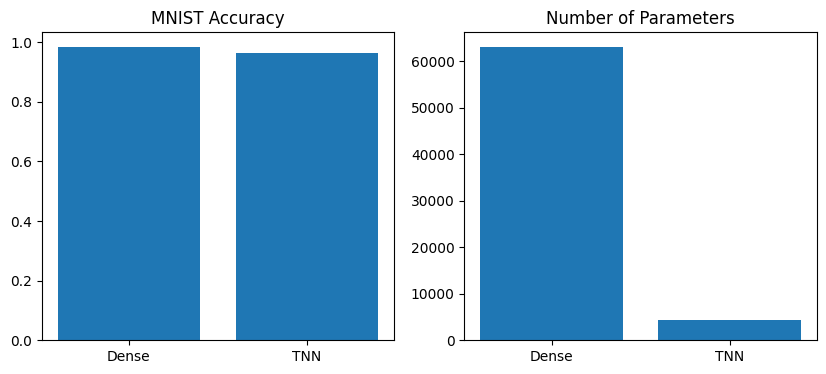

In [15]:
dense_p = count_params(dense)
tnn_p = count_params(tnn)

print("===== MNIST RESULTS =====")
print(f"Dense Accuracy: {dense_acc:.4f}")
print(f"TNN Accuracy:   {tnn_acc:.4f}")
print(f"Parameter reduction: {1 - tnn_p/dense_p:.2%}")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.bar(["Dense","TNN"], [dense_acc, tnn_acc])
plt.title("MNIST Accuracy")

plt.subplot(1,2,2)
plt.bar(["Dense","TNN"], [dense_p, tnn_p])
plt.title("Number of Parameters")∫

plt.show()